In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

df = pd.read_csv("netflix_movies&shows.csv")

print(df.head())

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

In [4]:
print("Shape:", df.shape)
print(df.info())

Shape: (8807, 12)
<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB
None


In [5]:
print(df.isnull().sum())

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [6]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (8807, 12)


In [7]:
# Extract numeric value from duration
df["duration_num"] = df["duration"].str.extract(r"(\d+)").astype(float)

# Select required features
features = [
    "release_year",
    "type",
    "rating"
]

# Remove rows with missing values
df = df.dropna(subset=features + ["duration_num"])

# Convert categorical columns into numerical columns
df = pd.get_dummies(
    df,
    columns=["type", "rating"],
    drop_first=True
)

print(df.head())

  show_id                  title         director  \
0      s1   Dick Johnson Is Dead  Kirsten Johnson   
1      s2          Blood & Water              NaN   
2      s3              Ganglands  Julien Leclercq   
3      s4  Jailbirds New Orleans              NaN   
4      s5           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year   duration  \
0  September 25, 2021          2020     90 min   
1  September 24, 2021          2021  2 Seasons   
2  September 24, 2021          2021   1 Season   
3  September 24, 2021          2021   1 Season   
4  S

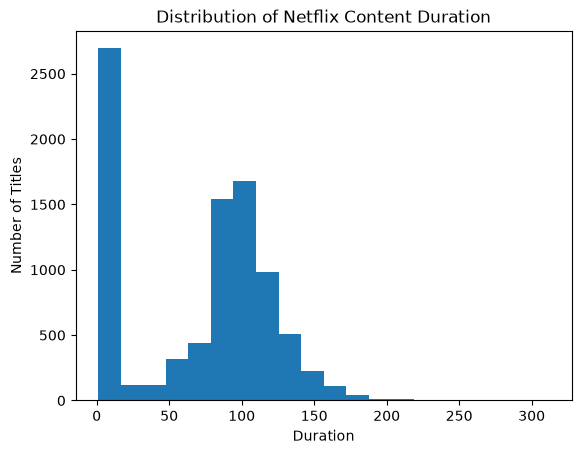

In [10]:
plt.hist(
    df["duration_num"],
    bins=20
)

plt.title("Distribution of Netflix Content Duration")
plt.xlabel("Duration")
plt.ylabel("Number of Titles")

plt.show()

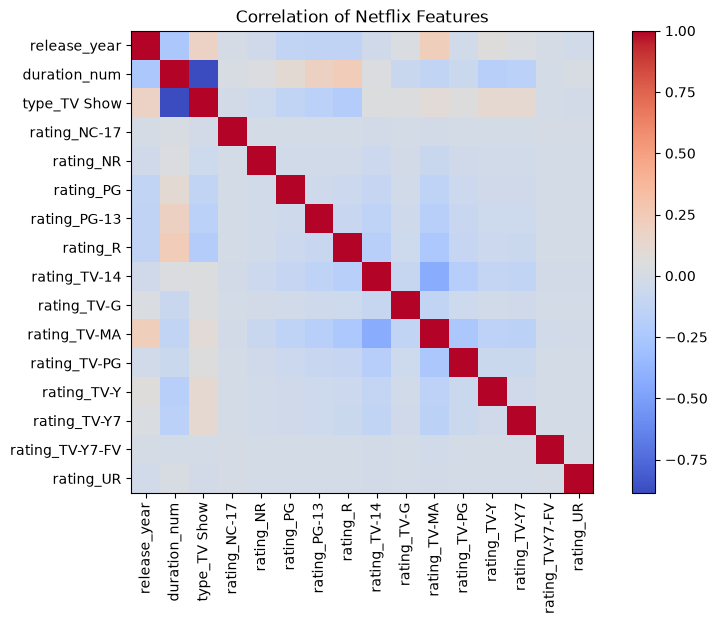

In [11]:
plt.figure(figsize=(10, 6))

correlation = df.corr(numeric_only=True)

plt.imshow(correlation, cmap="coolwarm")

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation of Netflix Features")

plt.show()

In [16]:
print(df.columns.tolist())

['show_id', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'duration', 'listed_in', 'description', 'duration_num', 'type_TV Show', 'rating_NC-17', 'rating_NR', 'rating_PG', 'rating_PG-13', 'rating_R', 'rating_TV-14', 'rating_TV-G', 'rating_TV-MA', 'rating_TV-PG', 'rating_TV-Y', 'rating_TV-Y7', 'rating_TV-Y7-FV', 'rating_UR']


In [17]:
X = df[
    [
        "release_year",
        "duration_num"
    ]
].copy()

# duration_num is the target, so remove it from X
X = X.drop("duration_num", axis=1)

y = df["duration_num"]

print("Data prepared")
print("X shape:", X.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Data split completed")

model = RandomForestRegressor(
    n_estimators=20,
    random_state=42,
    n_jobs=-1
)

print("Training model...")

model.fit(X_train, y_train)

print("Model training completed")

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("R2 Score:", r2)

Data prepared
X shape: (8800, 1)
Data split completed
Training model...
Model training completed
Mean Absolute Error: 42.177251807132436
R2 Score: 0.07800941991189125
